<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/MultiArmedBanditAlgorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Code for Interview Purpose**

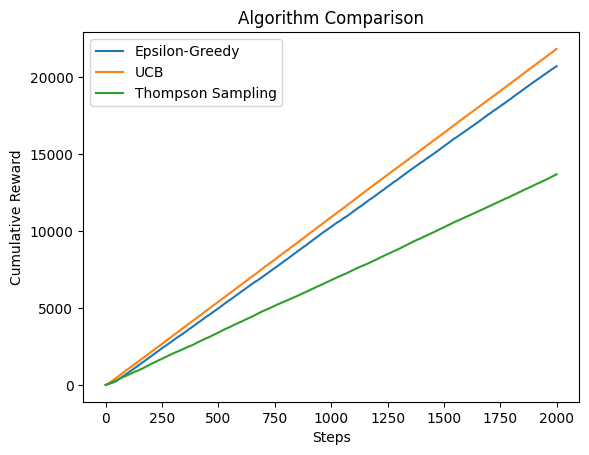

In [5]:
import numpy as np
import matplotlib.pyplot as plt

k = 11
steps = 2000
true_means = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

def get_reward(a):
    return np.random.normal(true_means[a], 1)

def epsilon_greedy():
    Q = np.zeros(k)
    N = np.zeros(k)
    rewards = []

    for t in range(steps):
        if np.random.rand() < 0.1:
            action = np.random.randint(k)
        else:
            action = np.argmax(Q)

        reward = get_reward(action)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

        rewards.append(reward)

    return np.cumsum(rewards)


def ucb():
    Q = np.zeros(k)
    N = np.zeros(k)
    rewards = []

    for t in range(1, steps + 1):
        if t <= k:
            action = t - 1
        else:
            action = np.argmax(Q + 2 * np.sqrt(np.log(t) / N))

        reward = get_reward(action)

        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]

        rewards.append(reward)

    return np.cumsum(rewards)


def thompson():
    alpha = np.ones(k)
    beta = np.ones(k)
    rewards = []

    for t in range(steps):
        samples = np.random.beta(alpha, beta)
        action = np.argmax(samples)

        reward = get_reward(action)

        r = 1 if reward > 0 else 0
        alpha[action] += r
        beta[action] += (1 - r)

        rewards.append(reward)

    return np.cumsum(rewards)


# Run all
eg = epsilon_greedy()
ucb_res = ucb()
ts = thompson()

# Plot
plt.plot(eg, label="Epsilon-Greedy")
plt.plot(ucb_res, label="UCB")
plt.plot(ts, label="Thompson Sampling")

plt.xlabel("Steps")
plt.ylabel("Cumulative Reward")
plt.title("Algorithm Comparison")
plt.legend()
plt.show()

# **Production Level Code**

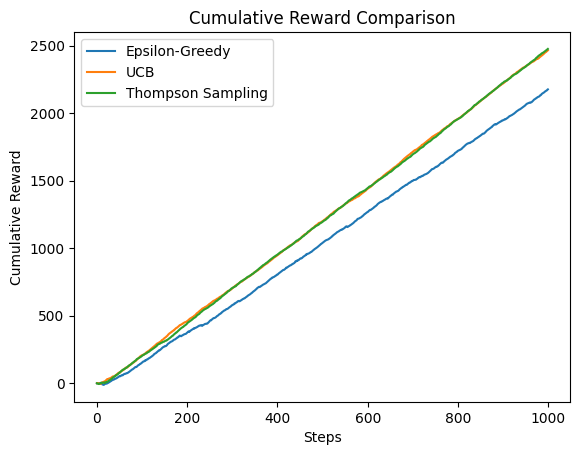

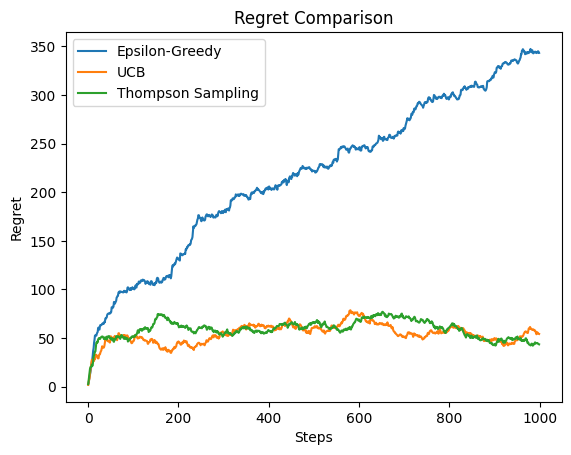

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Bandit Environment
# =========================
class Bandit:
    def __init__(self, k=10):
        """
        k = number of arms (actions)
        Each arm has a true reward distribution (unknown to agent)
        """
        self.k = k

        # True mean reward of each arm (unknown to agent)
        # These are sampled randomly from normal distribution
        self.true_means = np.random.normal(0, 1, k)

    def pull(self, action):
        """
        Simulate pulling an arm.
        Returns reward sampled from a normal distribution
        centered at the true mean of that arm.
        """
        return np.random.normal(self.true_means[action], 1)


# =========================
# Base Agent Class
# =========================
class Agent:
    def __init__(self, k):
        self.k = k

        # Q(a): estimated reward of each arm
        self.Q = np.zeros(k)

        # N(a): number of times each arm has been selected
        self.N = np.zeros(k)

        # Total accumulated reward
        self.total_reward = 0

    def update(self, action, reward):
        """
        Update Q(a) using incremental average formula:

        Q(a) ← Q(a) + (1 / N(a)) * (reward - Q(a))
        """
        self.N[action] += 1

        # Incremental update (running average)
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


# =========================
# ε-Greedy Agent
# =========================
class EpsilonGreedy(Agent):
    def __init__(self, k, epsilon=0.1):
        super().__init__(k)
        self.epsilon = epsilon  # Probability of exploration

    def select_action(self):
        """
        With probability ε → explore (random arm)
        With probability 1-ε → exploit (best known arm)
        """
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.k)  # Explore
        return np.argmax(self.Q)  # Exploit


# =========================
# UCB Agent
# =========================
class UCB(Agent):
    def __init__(self, k, c=2):
        super().__init__(k)
        self.c = c  # Exploration parameter
        self.t = 0  # Total steps

    def select_action(self):
        """
        UCB formula:
        Q(a) + c * sqrt( log(t) / N(a) )
        """
        self.t += 1

        # Ensure each arm is selected at least once
        for i in range(self.k):
            if self.N[i] == 0:
                return i

        # Compute UCB values for all arms
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)

        # Select arm with highest UCB value
        return np.argmax(ucb_values)


# =========================
# Thompson Sampling Agent
# =========================
class ThompsonSampling:
    def __init__(self, k):
        self.k = k

        # Alpha and Beta parameters for Beta distribution
        # Initially all arms assumed equally likely
        self.alpha = np.ones(k)
        self.beta = np.ones(k)

        self.total_reward = 0

    def select_action(self):
        """
        Sample from Beta distribution for each arm
        and choose the arm with highest sample value
        """
        samples = np.random.beta(self.alpha, self.beta)
        return np.argmax(samples)

    def update(self, action, reward):
        """
        Update Beta distribution parameters

        Convert reward into binary (0 or 1)
        because Thompson Sampling here assumes Bernoulli rewards
        """
        reward_binary = 1 if reward > 0 else 0

        # Update success/failure counts
        self.alpha[action] += reward_binary
        self.beta[action] += (1 - reward_binary)


# =========================
# Simulation Function
# =========================
def run(agent, bandit, steps=1000):
    """
    Run simulation for a given agent and bandit

    Returns:
    - cumulative rewards over time
    - regret over time
    """
    rewards = []  # Store cumulative rewards
    regret = []   # Store regret values

    # Best possible expected reward (optimal arm)
    optimal_mean = np.max(bandit.true_means)

    total_reward = 0

    for t in range(steps):
        # Step 1: Select action
        action = agent.select_action()

        # Step 2: Get reward from environment
        reward = bandit.pull(action)

        # Step 3: Update agent knowledge
        agent.update(action, reward)

        # Step 4: Update total reward
        total_reward += reward
        rewards.append(total_reward)

        # Step 5: Calculate regret
        regret.append((t + 1) * optimal_mean - total_reward)

    return rewards, regret


# =========================
# Main Experiment
# =========================
def main():
    k = 10       # Number of arms
    steps = 1000 # Number of iterations

    # Create bandit environment
    bandit = Bandit(k)

    # Initialize agents
    agents = {
        "Epsilon-Greedy": EpsilonGreedy(k, epsilon=0.1),
        "UCB": UCB(k, c=2),
        "Thompson Sampling": ThompsonSampling(k)
    }

    results_rewards = {}
    results_regret = {}

    # Run simulation for each algorithm
    for name, agent in agents.items():
        rewards, regret = run(agent, bandit, steps)
        results_rewards[name] = rewards
        results_regret[name] = regret

    # =========================
    # Plot Cumulative Reward
    # =========================
    plt.figure()
    for name in agents:
        plt.plot(results_rewards[name], label=name)

    plt.xlabel("Steps")
    plt.ylabel("Cumulative Reward")
    plt.title("Cumulative Reward Comparison")
    plt.legend()
    plt.show()

    # =========================
    # Plot Regret
    # =========================
    plt.figure()
    for name in agents:
        plt.plot(results_regret[name], label=name)

    plt.xlabel("Steps")
    plt.ylabel("Regret")
    plt.title("Regret Comparison")
    plt.legend()
    plt.show()


# Entry point
if __name__ == "__main__":
    main()